In [1]:
%pip install torch


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install sentence-transformers transformers


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
import torch
from sentence_transformers import SentenceTransformer
import transformers
import warnings
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import os
import json

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 1000)

print("Libraries imported successfully! Environment is ready.")

/home/chandima-bandara/Desktop/intelligent-employee-task-allocation/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully! Environment is ready.


In [4]:
file_path = "../data/processed/preprocessed_employee_task_data.csv"
df = pd.read_csv(file_path)

print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")

print("--- Column Names & Data Types ---")
print(df.dtypes.to_string())
print("\n")

print("--- Missing-Value Summary ---")
missing_values = df.isnull().sum()
missing_filtered = missing_values[missing_values > 0]
if missing_filtered.empty:
    print("No missing values found (excluding deadlines).")
else:
    print(missing_filtered.to_string())
print("\n")

print("--- Unique Values for Key Columns ---")
key_columns = [
    "Employee_ID",
    "Task_ID",
    "Project_Name",
    "Employee_Department",
    "Employee_Job_Position",
    "Task_Priority"
]
for col in key_columns:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} unique values")
print("\n")

print("--- First 5 Rows ---")
display(df.head())

Dataset Shape: 11,630 rows x 19 columns

--- Column Names & Data Types ---
Date                                            str
Task_ID                                         str
Task_Name                                       str
Work_Description                                str
Hours_Spent                                 float64
Project_Name                                    str
Employee_ID                                     str
Employee_Department                             str
Employee_Job_Position                           str
Task_Description                                str
FLAG_LEAKAGE_Timesheet_Work_Logs                str
Task_Priority                                   str
Estimated_Planned_Hours                     float64
FLAG_LEAKAGE_Actual_Hours_Spent             float64
FLAG_LEAKAGE_Timesheet_Logs_Count             int64
FLAG_LEAKAGE_Task_Stage                         str
Created_Date                                    str
Deadline_Date                            

,Date,Task_ID,Task_Name,Work_Description,Hours_Spent,Project_Name,Employee_ID,Employee_Department,Employee_Job_Position,Task_Description,FLAG_LEAKAGE_Timesheet_Work_Logs,Task_Priority,Estimated_Planned_Hours,FLAG_LEAKAGE_Actual_Hours_Spent,FLAG_LEAKAGE_Timesheet_Logs_Count,FLAG_LEAKAGE_Task_Stage,Created_Date,Deadline_Date,FLAG_LEAKAGE_All_Collaborating_Employees
0,2026-09-14,TSK-1640,odoo sh maintain,db backup and restore in test,0.25,Hovael Project,EMP-11,Research And Development (R&D),Team Lead - Research And Development (R&D),odoo sh maintain. work details: add addons t the server | get backup from live and restore in test.get backup test and send both to nadeesha | add qutation summary and test why it is not installin...,add addons t the server | get backup from live and restore in test.get backup test and send both to nadeesha | add qutation summary and test why it is not installing and install the basereport xls...,Low,0.0,14.25,27,Project Preparation,2026-02-05,NaN,W M I L Wijesinghe
1,2026-09-14,TSK-1881,odoo sh maintain,db backup and restore in test,0.25,Ceylon Eco Spices,EMP-11,Research And Development (R&D),Team Lead - Research And Development (R&D),odoo sh maintain. work details: add addon and test | get odoo sh live ackup and restore in test | add quick book.get from milanka | backup restore to test | add addons | add addons and get backup ...,add addon and test | get odoo sh live ackup and restore in test | add quick book.get from milanka | backup restore to test | add addons | add addons and get backup adn restore in live | add invent...,Low,0.0,6.50,13,Developments,2026-03-19,NaN,W M I L Wijesinghe
2,2026-09-14,TSK-182,odoo.sh maintaing,add addons,0.25,Mihiri Bakemart (Pvt)Ltd - Development,EMP-11,Research And Development (R&D),Team Lead - Research And Development (R&D),odoo.sh maintaing. work details: add all addon and build and test on the odoo sh | clean and refresh the odoosh | add addon and build thenew build and test th addons | add addon and test | add add...,add all addon and build and test on the odoo sh | clean and refresh the odoosh | add addon and build thenew build and test th addons | add addon and test | add addon and test addon witchanuka and ...,Low,0.0,40.75,29,Ongoing,2025-06-09,NaN,W M I L Wijesinghe
3,2026-09-14,TSK-2884,development meeting,/,0.00,Cygnus One,EMP-55,Colombo Branch,Project Manager,development meeting. work details: intern development hoveal project meeting | meeting milan and plan the developments | hovael meeting | sewinco development discussion | requirment discuss hovael...,"intern development hoveal project meeting | meeting milan and plan the developments | hovael meeting | sewinco development discussion | requirment discuss hovael,mihiri and steel mart | rfq app ch...",Low,0.0,9.42,13,Miscellaneous,2026-07-06,NaN,"W M I L Wijesinghe, K R V Dias, A R M S Madusanka, Malshi Jayanthi"
4,2026-09-14,TSK-405,other tasks (mention on description),get privillages to charith's new github account on odoo sh projects and the all repositories,0.50,Cygnus One,EMP-11,Research And Development (R&D),Team Lead - Research And Development (R&D),other tasks (mention on description). work details: self ssl setup on vps | preparing report list | richy sql table exporting | create material issue video clip | added anthonies domain | create g...,self ssl setup on vps | preparing report list | richy sql table exporting | create material issue video clip | added anthonies domain | create grn import template | landed cost | create demo datab...,Low,0.0,162.18,69,Miscellaneous,2025-07-14,NaN,"H.M.C.S Thilakarathna, Sadaruwan Bandara, L H P S S Pathirana, I G C Bandara, W M I L Wijesinghe, G L Sachini"


In [5]:
TARGET = "Employee_ID"
print(f"Model Objective: Recommend/rank {TARGET} for newly created tasks.\n")

leakage_columns = [
    "Actual_Hours_Spent",
    "Timesheet_Work_Logs",
    "Timesheet_Logs_Count",
    "Task_Stage",
    "All_Collaborating_Employees"
]

print("Leakage columns identified and isolated (Not deleted).")
post_assignment_features = leakage_columns + ["Work_Description"]

Model Objective: Recommend/rank Employee_ID for newly created tasks.

Leakage columns identified and isolated (Not deleted).


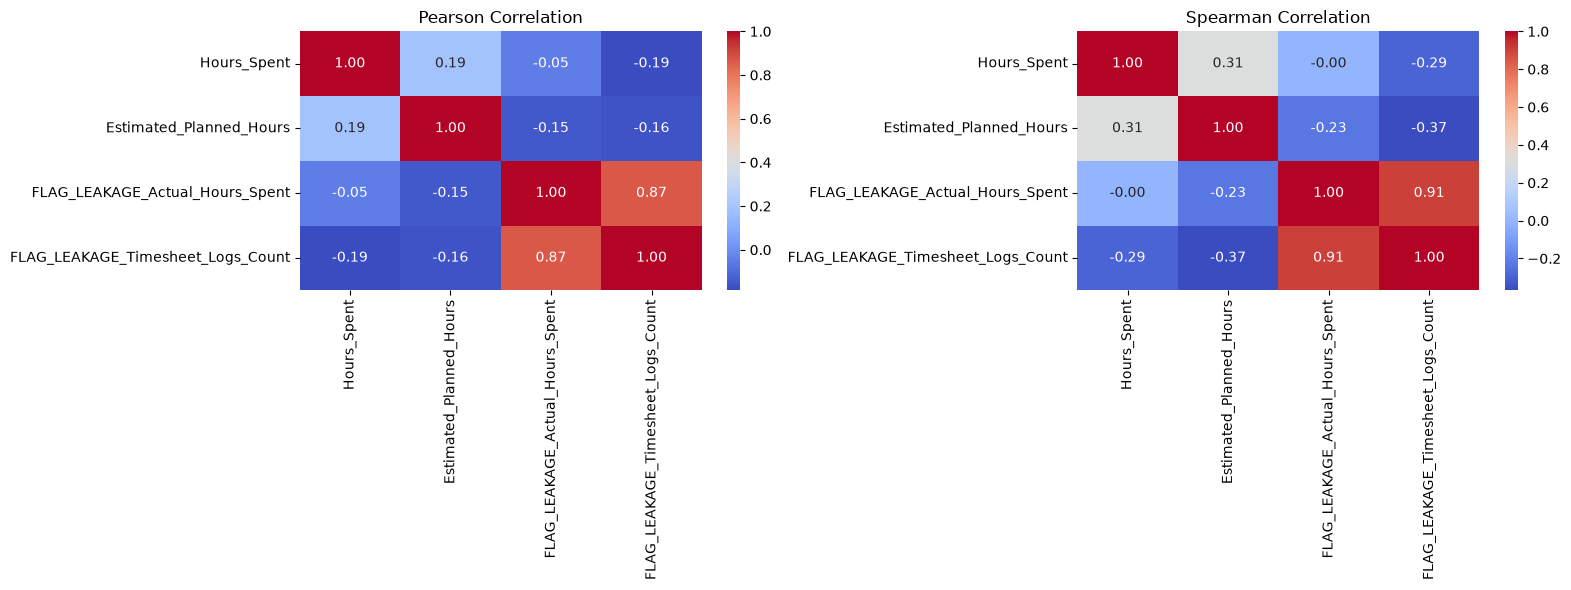

Highly Correlated Numerical Pairs (Pearson | >= 0.70):
 - FLAG_LEAKAGE_Actual_Hours_Spent & FLAG_LEAKAGE_Timesheet_Logs_Count: 0.869

Highly Correlated Numerical Pairs (Spearman | >= 0.70):
 - FLAG_LEAKAGE_Actual_Hours_Spent & FLAG_LEAKAGE_Timesheet_Logs_Count: 0.905

--- Mutual Information Scores (Target: Employee_ID) ---


,Feature,Mutual_Information
4,Employee_Job_Position,2.519176
1,Task_Name,2.264791
3,Employee_Department,1.309500
0,Project_Name,1.226753
2,Task_Priority,0.032660



--- Target Distribution (Employee_ID) ---
Total Unique Employees: 46
Average Tasks per Employee: 237.35
Median Tasks per Employee: 119.00
Most Frequently Assigned: EMP-5 (1010 tasks)
Least Frequently Assigned: EMP-1 (2 tasks)

Top 10 Employees by Assignment Count:


,Task_Count,count
0,EMP-5,1010
1,EMP-10,959
2,EMP-11,946
3,EMP-17,604
4,EMP-4,547
5,EMP-16,528
6,EMP-12,516
7,EMP-27,508
8,EMP-7,498
9,EMP-21,456



Bottom 5 Employees by Assignment Count:


,Task_Count,count
0,EMP-59,12
1,EMP-24,9
2,EMP-25,6
3,EMP-67,2
4,EMP-1,2


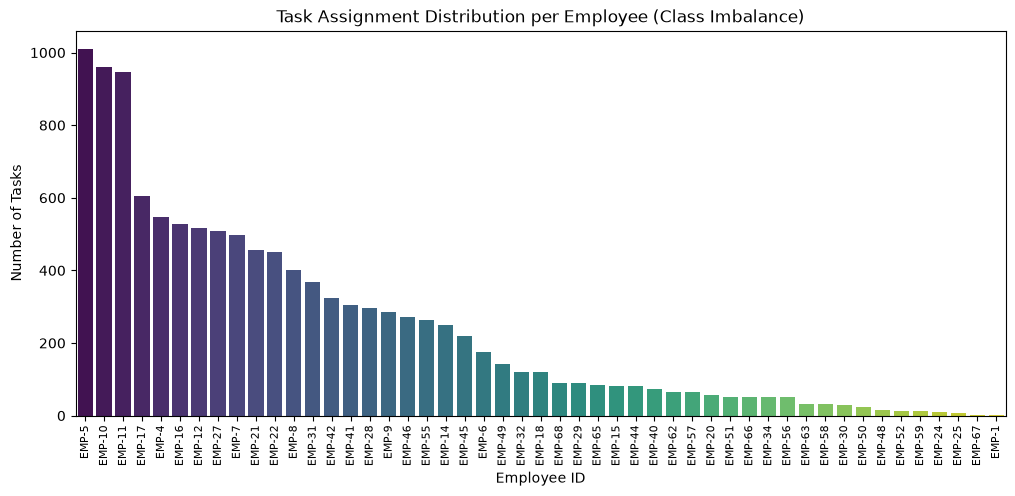

In [6]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "Employee_ID" in numerical_cols: numerical_cols.remove("Employee_ID")
if "Task_ID" in numerical_cols: numerical_cols.remove("Task_ID")

pearson_corr = df[numerical_cols].corr(method="pearson")
spearman_corr = df[numerical_cols].corr(method="spearman")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0])
axes[0].set_title("Pearson Correlation")
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1])
axes[1].set_title("Spearman Correlation")
plt.tight_layout()
plt.show()

def get_highly_correlated_pairs(corr_matrix, threshold=0.70):
    pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
    return pairs

print("Highly Correlated Numerical Pairs (Pearson | >= 0.70):")
pearson_pairs = get_highly_correlated_pairs(pearson_corr)
for p in pearson_pairs: print(f" - {p[0]} & {p[1]}: {p[2]:.3f}")

print("\nHighly Correlated Numerical Pairs (Spearman | >= 0.70):")
spearman_pairs = get_highly_correlated_pairs(spearman_corr)
for p in spearman_pairs: print(f" - {p[0]} & {p[1]}: {p[2]:.3f}")

from sklearn.metrics import mutual_info_score
print("\n--- Mutual Information Scores (Target: Employee_ID) ---")
cat_features = [
    "Project_Name",
    "Task_Name",
    "Task_Priority",
    "Employee_Department",
    "Employee_Job_Position"
]
mi_scores = []
for col in cat_features:
    if col in df.columns:
        col_data = df[col].fillna("Unknown").astype(str)
        target_data = df["Employee_ID"].astype(str)
        mi = mutual_info_score(col_data, target_data)
        mi_scores.append({"Feature": col, "Mutual_Information": mi})
mi_df = pd.DataFrame(mi_scores).sort_values(by="Mutual_Information", ascending=False)
display(mi_df)

print("\n--- Target Distribution (Employee_ID) ---")
employee_counts = df["Employee_ID"].value_counts()
print(f"Total Unique Employees: {employee_counts.nunique()}")
print(f"Average Tasks per Employee: {employee_counts.mean():.2f}")
print(f"Median Tasks per Employee: {employee_counts.median():.2f}")
print(f"Most Frequently Assigned: {employee_counts.index[0]} ({employee_counts.iloc[0]} tasks)")
print(f"Least Frequently Assigned: {employee_counts.index[-1]} ({employee_counts.iloc[-1]} tasks)\n")

print("Top 10 Employees by Assignment Count:")
display(employee_counts.head(10).reset_index().rename(columns={"index": "Employee_ID", "Employee_ID": "Task_Count"}))

print("\nBottom 5 Employees by Assignment Count:")
display(employee_counts.tail(5).reset_index().rename(columns={"index": "Employee_ID", "Employee_ID": "Task_Count"}))

plt.figure(figsize=(12, 5))
sns.barplot(x=employee_counts.index, y=employee_counts.values, palette="viridis")
plt.title("Task Assignment Distribution per Employee (Class Imbalance)")
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Number of Tasks")
plt.xlabel("Employee ID")
plt.show()

In [7]:
df["Task_Text"] = (
    df["Task_Name"].astype(str).fillna("") + " " +
    df["Task_Description"].astype(str).fillna("")
).str.strip()

df["Task_Text_Length"] = df["Task_Text"].str.len()
df["Task_Word_Count"] = df["Task_Text"].str.split().str.len()
df["Task_Description_Length"] = df["Task_Description"].astype(str).fillna("").str.len()
df["Task_Name_Length"] = df["Task_Name"].astype(str).fillna("").str.len()

df["Has_Task_Description"] = (df["Task_Description_Length"] > 0).astype(int)

print("--- New Deterministic Text Features ---")
display(df[["Task_Name", "Task_Text", "Task_Text_Length", "Task_Word_Count", "Has_Task_Description"]].head())

--- New Deterministic Text Features ---


,Task_Name,Task_Text,Task_Text_Length,Task_Word_Count,Has_Task_Description
0,odoo sh maintain,odoo sh maintain odoo sh maintain. work details: add addons t the server | get backup from live and restore in test.get backup test and send both to nadeesha | add qutation summary and test why it...,1014,206,1
1,odoo sh maintain,odoo sh maintain odoo sh maintain. work details: add addon and test | get odoo sh live ackup and restore in test | add quick book.get from milanka | backup restore to test | add addons | add addon...,452,91,1
2,odoo.sh maintaing,odoo.sh maintaing odoo.sh maintaing. work details: add all addon and build and test on the odoo sh | clean and refresh the odoosh | add addon and build thenew build and test th addons | add addon ...,1258,247,1
3,development meeting,development meeting development meeting. work details: intern development hoveal project meeting | meeting milan and plan the developments | hovael meeting | sewinco development discussion | requi...,397,59,1
4,other tasks (mention on description),other tasks (mention on description) other tasks (mention on description). work details: self ssl setup on vps | preparing report list | richy sql table exporting | create material issue video cli...,2869,504,1


In [8]:
date_cols = ["Created_Date", "Deadline_Date"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

if "Created_Date" in df.columns:
    df["Created_Year"] = df["Created_Date"].dt.year
    df["Created_Month"] = df["Created_Date"].dt.month
    df["Created_DayOfWeek"] = df["Created_Date"].dt.dayofweek
    df["Created_Quarter"] = df["Created_Date"].dt.quarter

if "Created_Date" in df.columns and "Deadline_Date" in df.columns:
    df["Days_To_Deadline"] = (df["Deadline_Date"] - df["Created_Date"]).dt.days
    df["Has_Deadline"] = df["Deadline_Date"].notnull().astype(int)

print("--- New Date-Based Features ---")
display(df[["Created_Date", "Created_Month", "Created_DayOfWeek", "Deadline_Date", "Days_To_Deadline", "Has_Deadline"]].head())

--- New Date-Based Features ---


,Created_Date,Created_Month,Created_DayOfWeek,Deadline_Date,Days_To_Deadline,Has_Deadline
0,2026-02-05,2,3,NaT,NaN,0
1,2026-03-19,3,3,NaT,NaN,0
2,2025-06-09,6,0,NaT,NaN,0
3,2026-07-06,7,0,NaT,NaN,0
4,2025-07-14,7,0,NaT,NaN,0


In [9]:
df["Planned_Hours_Log"] = np.log1p(df["Estimated_Planned_Hours"])

bins = [-1, 8, 40, float("inf")]
labels = ["Small", "Medium", "Large"]
df["Planned_Task_Size"] = pd.cut(df["Estimated_Planned_Hours"], bins=bins, labels=labels)

print("--- Planned-Hours Features ---")
display(df[["Estimated_Planned_Hours", "Planned_Hours_Log", "Planned_Task_Size"]].head(10))

--- Planned-Hours Features ---


,Estimated_Planned_Hours,Planned_Hours_Log,Planned_Task_Size
0,0.0,0.000000,Small
1,0.0,0.000000,Small
2,0.0,0.000000,Small
3,0.0,0.000000,Small
4,0.0,0.000000,Small
5,0.0,0.000000,Small
6,0.0,0.000000,Small
7,0.0,0.000000,Small
8,0.0,0.000000,Small
9,16.0,2.833213,Medium


In [10]:
print("Loading sentence-transformers/all-MiniLM-L6-v2...")
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

skill_taxonomy = {
    "Odoo ERP Development": "Odoo ERP development, addons, github, and technical maintenance",
    "Database Management": "Database management, SQL, db backup, data import, and restore",
    "Server Administration": "Server administration, VPS setup, SSL, and deployment",
    "Project Management": "Project management, meetings, scrum, and planning",
    "Software Testing": "Software testing, UAT session, quality assurance, and bug fixing",
    "Web Development": "Web development, frontend, and backend coding",
    "Client & Functional Support": "Client support, functional support, live support, and troubleshooting",
    "Documentation": "Preparing reports, blueprints, documentation, and lists",
    "Training & Mentorship": "Intern training, presale training, conducting training sessions, and explaining processes"
}

skill_names = list(skill_taxonomy.keys())
skill_descriptions = list(skill_taxonomy.values())

print("Embedding the skill taxonomy...")
skill_embeddings = model.encode(skill_descriptions, convert_to_numpy=True)

print(f"Embedding {len(df)} task descriptions...")
task_texts = df["Task_Text"].astype(str).fillna("").tolist()
task_embeddings = model.encode(task_texts, convert_to_numpy=True, show_progress_bar=True)

print("Calculating semantic similarities...")
similarities = cosine_similarity(task_embeddings, skill_embeddings)

THRESHOLD = 0.30
extracted_skills_list = []
skill_counts = []
debug_details = []

for i in range(len(task_texts)):
    task_sims = similarities[i]
    matched_indices = np.where(task_sims >= THRESHOLD)[0]

    if len(matched_indices) > 0:
        sorted_matches = sorted(matched_indices, key=lambda idx: task_sims[idx], reverse=True)
        skills_str = " | ".join([skill_names[idx] for idx in sorted_matches])
        debug_str = " | ".join([f"{skill_names[idx]} ({task_sims[idx]:.2f})" for idx in sorted_matches])
    else:
        skills_str = "Uncategorized"
        debug_str = "None"

    extracted_skills_list.append(skills_str)
    skill_counts.append(len(matched_indices))
    debug_details.append(debug_str)

df["Task_Skills"] = extracted_skills_list
df["Task_Skill_Count"] = skill_counts
df["Debug_Skill_Scores"] = debug_details

print("--- Manual Review: Semantic Skill Extraction ---")
print(f"Threshold used: {THRESHOLD}")
uncat_count = (df['Task_Skills'] == 'Uncategorized').sum()
print(f"Total Uncategorized tasks: {uncat_count}")

sample_review = df[["Task_Text", "Task_Skills", "Debug_Skill_Scores"]].sample(30, random_state=42)

with pd.option_context("display.max_colwidth", None):
    display(sample_review)


Loading sentence-transformers/all-MiniLM-L6-v2...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1872.65it/s]


Embedding the skill taxonomy...
Embedding 11630 task descriptions...


Batches: 100%|██████████| 364/364 [12:46<00:00,  2.11s/it]


Calculating semantic similarities...
--- Manual Review: Semantic Skill Extraction ---
Threshold used: 0.3
Total Uncategorized tasks: 2593


Task_Text  \
1275                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [11]:
train_ratio  = 0.70
val_ratio    = 0.15
test_ratio   = 0.15
RANDOM_STATE = 42

unique_task_ids = df["Task_ID"].dropna().unique().tolist()
print("Total unique tasks in dataset:", len(unique_task_ids))

train_task_ids, temp_task_ids = train_test_split(
    unique_task_ids,
    test_size=(val_ratio + test_ratio),
    random_state=RANDOM_STATE
)
val_task_ids, test_task_ids = train_test_split(
    temp_task_ids,
    test_size=(test_ratio / (val_ratio + test_ratio)),
    random_state=RANDOM_STATE
)

train_df = df[df["Task_ID"].isin(train_task_ids)].copy()
val_df   = df[df["Task_ID"].isin(val_task_ids)].copy()
test_df  = df[df["Task_ID"].isin(test_task_ids)].copy()

train_tasks = set(train_df["Task_ID"])
val_tasks   = set(val_df["Task_ID"])
test_tasks  = set(test_df["Task_ID"])

train_val_overlap  = train_tasks.intersection(val_tasks)
train_test_overlap = train_tasks.intersection(test_tasks)
val_test_overlap   = val_tasks.intersection(test_tasks)

print("Train unique tasks:      ", len(train_tasks))
print("Validation unique tasks: ", len(val_tasks))
print("Test unique tasks:       ", len(test_tasks))
print("Train/Validation task overlap:", len(train_val_overlap))
print("Train/Test task overlap:      ", len(train_test_overlap))
print("Validation/Test task overlap: ", len(val_test_overlap))

assert len(train_val_overlap)  == 0, "LEAKAGE: Train/Val Task_ID overlap!"
assert len(train_test_overlap) == 0, "LEAKAGE: Train/Test Task_ID overlap!"
assert len(val_test_overlap)   == 0, "LEAKAGE: Val/Test Task_ID overlap!"

print("All task-leakage assertions passed!")

print(f"Train rows: {len(train_df):,}  Val rows: {len(val_df):,}  Test rows: {len(test_df):,}")


Total unique tasks in dataset: 2442
Train unique tasks:       1709
Validation unique tasks:  366
Test unique tasks:        367
Train/Validation task overlap: 0
Train/Test task overlap:       0
Validation/Test task overlap:  0
All task-leakage assertions passed!
Train rows: 8,314  Val rows: 1,588  Test rows: 1,728


In [12]:
print("PART 11: TRAINING-ONLY EMPLOYEE SKILL AND HISTORICAL PROFILES")
print("Profiles are built from train_df only. Val/test rows are excluded.")

SKILL_TAXONOMY = [
    "Odoo ERP Development",
    "Database Management",
    "Server Administration",
    "Project Management",
    "Software Testing",
    "Web Development",
    "Client & Functional Support",
    "Documentation",
    "Training & Mentorship",
]

SKILL_COLUMNS = [
    "Skill_" + s.replace(" ", "_").replace("&", "and").replace("/", "_")
    for s in SKILL_TAXONOMY
]

for skill, col in zip(SKILL_TAXONOMY, SKILL_COLUMNS):
    for dset in [train_df, val_df, test_df]:
        if col not in dset.columns:
            dset[col] = (
                dset["Task_Skills"]
                .astype(str)
                .str.contains(skill, regex=False, na=False)
                .astype(int)
            )

for dset in [train_df, val_df, test_df]:
    dset["Task_Skill_Count"] = dset[SKILL_COLUMNS].sum(axis=1)

print("Skill columns:", SKILL_COLUMNS)
print("Train task skill count sample:")
print(train_df["Task_Skill_Count"].describe())

employee_skill_profiles = (
    train_df.groupby("Employee_ID")[SKILL_COLUMNS]
    .mean()
    .add_prefix("Employee_Profile_")
    .reset_index()
)

EMP_SKILL_PROFILE_COLS = [c for c in employee_skill_profiles.columns if c != "Employee_ID"]
print(f"Employee skill profiles: {employee_skill_profiles.shape}")
display(employee_skill_profiles.head(3))


PART 11: TRAINING-ONLY EMPLOYEE SKILL AND HISTORICAL PROFILES
Profiles are built from train_df only. Val/test rows are excluded.
Skill columns: ['Skill_Odoo_ERP_Development', 'Skill_Database_Management', 'Skill_Server_Administration', 'Skill_Project_Management', 'Skill_Software_Testing', 'Skill_Web_Development', 'Skill_Client_and_Functional_Support', 'Skill_Documentation', 'Skill_Training_and_Mentorship']
Train task skill count sample:
count    8314.000000
mean        1.773755
std         1.368276
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: Task_Skill_Count, dtype: float64
Employee skill profiles: (49, 10)


,Employee_ID,Employee_Profile_Skill_Odoo_ERP_Development,Employee_Profile_Skill_Database_Management,Employee_Profile_Skill_Server_Administration,Employee_Profile_Skill_Project_Management,Employee_Profile_Skill_Software_Testing,Employee_Profile_Skill_Web_Development,Employee_Profile_Skill_Client_and_Functional_Support,Employee_Profile_Skill_Documentation,Employee_Profile_Skill_Training_and_Mentorship
0,EMP-1,0.500000,0.000000,0.000000,0.500000,0.000000,0.0,0.000000,0.500000,0.500000
1,EMP-10,0.197411,0.000000,0.000000,0.061489,0.016181,0.0,0.033981,0.448220,0.024272
2,EMP-11,0.620186,0.002656,0.002656,0.409031,0.003984,0.0,0.029216,0.555113,0.073041


In [13]:
employee_historical_profiles = (
    train_df.groupby("Employee_ID")
    .agg(
        employee_historical_task_count=("Task_ID", "nunique"),
        employee_historical_avg_planned_hours=("Estimated_Planned_Hours", "mean"),
        employee_historical_avg_skill_count=("Task_Skill_Count", "mean"),
        employee_historical_unique_projects=("Project_Name", "nunique"),
        employee_historical_project_count=("Project_Name", "nunique"),
        employee_historical_avg_task_text_length=("Task_Text_Length", "mean"),
        employee_historical_avg_deadline_days=("Days_To_Deadline", "mean"),
    )
    .reset_index()
)
employee_historical_profiles["employee_log_task_count"] = np.log1p(
    employee_historical_profiles["employee_historical_task_count"]
)

print("Employee historical profiles:", employee_historical_profiles.shape)
display(employee_historical_profiles.describe())

project_train_stats = (
    train_df.groupby("Project_Name", as_index=False)
    .agg(
        Project_Task_Count_Train=("Task_ID", "nunique"),
        Project_Avg_Skill_Count_Train=("Task_Skill_Count", "mean"),
        Project_Avg_Planned_Hours_Train=("Estimated_Planned_Hours", "mean"),
    )
)

for dset in [train_df, val_df, test_df]:
    for col in ["Project_Task_Count_Train", "Project_Avg_Skill_Count_Train", "Project_Avg_Planned_Hours_Train"]:
        if col in dset.columns:
            dset.drop(columns=[col], inplace=True)
    merged = dset.merge(project_train_stats, on="Project_Name", how="left")
    for col in ["Project_Task_Count_Train", "Project_Avg_Skill_Count_Train", "Project_Avg_Planned_Hours_Train"]:
        dset[col] = merged[col].values

print("Project-level training stats merged into train/val/test.")


Employee historical profiles: (49, 9)


,employee_historical_task_count,employee_historical_avg_planned_hours,employee_historical_avg_skill_count,employee_historical_unique_projects,employee_historical_project_count,employee_historical_avg_task_text_length,employee_historical_avg_deadline_days,employee_log_task_count
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,34.000000,49.000000
mean,49.489796,7.565568,1.736931,11.102041,11.102041,2487.730412,74.505153,3.337467
std,47.461442,8.627786,0.703139,9.576980,9.576980,2398.666626,93.822861,1.225185
min,1.000000,0.000000,0.285714,1.000000,1.000000,95.000000,0.000000,0.693147
25%,9.000000,0.179104,1.172702,3.000000,3.000000,977.038647,6.618421,2.302585
50%,31.000000,4.697674,1.730769,9.000000,9.000000,1796.268362,36.708333,3.465736
75%,74.000000,12.700000,2.245714,14.000000,14.000000,3804.674286,110.353070,4.317488
max,178.000000,36.912281,3.692308,35.000000,35.000000,13338.500000,409.254545,5.187386


Project-level training stats merged into train/val/test.


In [14]:
output_dir = "../data/processed/split_datasets"
os.makedirs(output_dir, exist_ok=True)

LEAKAGE_COLS = [
    "Actual_Hours_Spent",
    "Timesheet_Work_Logs",
    "Timesheet_Logs_Count",
    "Task_Stage",
    "All_Collaborating_Employees",
    "Work_Description",
    "Employee_Name",
    "Debug_Skill_Scores",
    "Task_Skills",
]

final_train_df = train_df.drop(columns=[c for c in LEAKAGE_COLS if c in train_df.columns])
final_val_df   = val_df.drop(columns=[c for c in LEAKAGE_COLS if c in val_df.columns])
final_test_df  = test_df.drop(columns=[c for c in LEAKAGE_COLS if c in test_df.columns])

final_train_df.to_csv(f"{output_dir}/feature_engineered_train_dataset.csv", index=False)
final_val_df.to_csv(f"{output_dir}/feature_engineered_validation_dataset.csv", index=False)
final_test_df.to_csv(f"{output_dir}/feature_engineered_test_dataset.csv", index=False)
employee_skill_profiles.to_csv(f"{output_dir}/employee_skill_profiles.csv", index=False)
employee_historical_profiles.to_csv(f"{output_dir}/employee_historical_profiles.csv", index=False)

metadata = {
    "split_method": "Task_ID-based stratified split (no row-level mixing)",
    "random_seed": 42,
    "split_ratios": {"train": 0.70, "validation": 0.15, "test": 0.15},
    "n_train_tasks": int(final_train_df["Task_ID"].nunique()),
    "n_val_tasks": int(final_val_df["Task_ID"].nunique()),
    "n_test_tasks": int(final_test_df["Task_ID"].nunique()),
    "n_train_employees": int(train_df["Employee_ID"].nunique()),
    "leakage_columns_excluded": LEAKAGE_COLS,
    "task_skill_columns": SKILL_COLUMNS,
    "employee_skill_profile_cols": EMP_SKILL_PROFILE_COLS,
    "employee_historical_profile_cols": list(employee_historical_profiles.columns),
    "created_at": datetime.datetime.now().isoformat(),
    "source_file": "../data/processed/preprocessed_employee_task_data.csv",
    "train_shape": list(final_train_df.shape),
    "val_shape": list(final_val_df.shape),
    "test_shape": list(final_test_df.shape),
}
with open(f"{output_dir}/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("=" * 60)
print("NOTEBOOK 04 OUTPUT SUMMARY")
print("=" * 60)
print(f"feature_engineered_train_dataset.csv      : {final_train_df.shape}")
print(f"feature_engineered_validation_dataset.csv : {final_val_df.shape}")
print(f"feature_engineered_test_dataset.csv       : {final_test_df.shape}")
print(f"employee_skill_profiles.csv               : {employee_skill_profiles.shape}")
print(f"employee_historical_profiles.csv          : {employee_historical_profiles.shape}")
print(f"model_metadata.json                       : saved")
print(f"")
print(f"Task leakage: ZERO overlap across all splits")
print(f"Train employees: {int(train_df['Employee_ID'].nunique())}")
print(f"Skill columns: {SKILL_COLUMNS}")
print(f"Employee profile cols: {EMP_SKILL_PROFILE_COLS}")
display(final_train_df.head(2))


NOTEBOOK 04 OUTPUT SUMMARY
feature_engineered_train_dataset.csv      : (8314, 45)
feature_engineered_validation_dataset.csv : (1588, 45)
feature_engineered_test_dataset.csv       : (1728, 45)
employee_skill_profiles.csv               : (49, 10)
employee_historical_profiles.csv          : (49, 9)
model_metadata.json                       : saved

Task leakage: ZERO overlap across all splits
Train employees: 49
Skill columns: ['Skill_Odoo_ERP_Development', 'Skill_Database_Management', 'Skill_Server_Administration', 'Skill_Project_Management', 'Skill_Software_Testing', 'Skill_Web_Development', 'Skill_Client_and_Functional_Support', 'Skill_Documentation', 'Skill_Training_and_Mentorship']
Employee profile cols: ['Employee_Profile_Skill_Odoo_ERP_Development', 'Employee_Profile_Skill_Database_Management', 'Employee_Profile_Skill_Server_Administration', 'Employee_Profile_Skill_Project_Management', 'Employee_Profile_Skill_Software_Testing', 'Employee_Profile_Skill_Web_Development', 'Employee_Pr

,Date,Task_ID,Task_Name,Hours_Spent,Project_Name,Employee_ID,Employee_Department,Employee_Job_Position,Task_Description,FLAG_LEAKAGE_Timesheet_Work_Logs,Task_Priority,Estimated_Planned_Hours,FLAG_LEAKAGE_Actual_Hours_Spent,FLAG_LEAKAGE_Timesheet_Logs_Count,FLAG_LEAKAGE_Task_Stage,Created_Date,Deadline_Date,FLAG_LEAKAGE_All_Collaborating_Employees,Task_Text,Task_Text_Length,Task_Word_Count,Task_Description_Length,Task_Name_Length,Has_Task_Description,Created_Year,Created_Month,Created_DayOfWeek,Created_Quarter,Days_To_Deadline,Has_Deadline,Planned_Hours_Log,Planned_Task_Size,Task_Skill_Count,Skill_Odoo_ERP_Development,Skill_Database_Management,Skill_Server_Administration,Skill_Project_Management,Skill_Software_Testing,Skill_Web_Development,Skill_Client_and_Functional_Support,Skill_Documentation,Skill_Training_and_Mentorship,Project_Task_Count_Train,Project_Avg_Skill_Count_Train,Project_Avg_Planned_Hours_Train
0,2026-09-14,TSK-1640,odoo sh maintain,0.25,Hovael Project,EMP-11,Research And Development (R&D),Team Lead - Research And Development (R&D),odoo sh maintain. work details: add addons t the server | get backup from live and restore in test.get backup test and send both to nadeesha | add qutation summary and test why it is not installin...,add addons t the server | get backup from live and restore in test.get backup test and send both to nadeesha | add qutation summary and test why it is not installing and install the basereport xls...,Low,0.0,14.25,27,Project Preparation,2026-02-05,NaT,W M I L Wijesinghe,odoo sh maintain odoo sh maintain. work details: add addons t the server | get backup from live and restore in test.get backup test and send both to nadeesha | add qutation summary and test why it...,1014,206,997,16,1,2026,2,3,1,NaN,0,0.0,Small,1,1,0,0,0,0,0,0,0,0,86,0.798611,20.715278
1,2026-09-14,TSK-1881,odoo sh maintain,0.25,Ceylon Eco Spices,EMP-11,Research And Development (R&D),Team Lead - Research And Development (R&D),odoo sh maintain. work details: add addon and test | get odoo sh live ackup and restore in test | add quick book.get from milanka | backup restore to test | add addons | add addons and get backup ...,add addon and test | get odoo sh live ackup and restore in test | add quick book.get from milanka | backup restore to test | add addons | add addons and get backup adn restore in live | add invent...,Low,0.0,6.50,13,Developments,2026-03-19,NaT,W M I L Wijesinghe,odoo sh maintain odoo sh maintain. work details: add addon and test | get odoo sh live ackup and restore in test | add quick book.get from milanka | backup restore to test | add addons | add addon...,452,91,435,16,1,2026,3,3,1,NaN,0,0.0,Small,2,1,0,0,0,0,0,0,1,0,42,1.447761,8.955224


In [15]:
print("PART 14: FINAL DATASET VALIDATION")

print(f"Final Train shape: {final_train_df.shape}")
print(f"Final Test shape: {final_test_df.shape}")
print(f"Final Validation shape: {final_val_df.shape}\n")

print(f"Train duplicate rows: {final_train_df.duplicated().sum()}")
print(f"Test duplicate rows: {final_test_df.duplicated().sum()}")
print(f"Val duplicate rows: {final_val_df.duplicated().sum()}\n")

print("--- Final Column List (Intended for Modelling) ---")
for col in final_train_df.columns:
    print(f"- {col}")

PART 14: FINAL DATASET VALIDATION
Final Train shape: (8314, 45)
Final Test shape: (1728, 45)
Final Validation shape: (1588, 45)

Train duplicate rows: 372
Test duplicate rows: 90
Val duplicate rows: 114

--- Final Column List (Intended for Modelling) ---
- Date
- Task_ID
- Task_Name
- Hours_Spent
- Project_Name
- Employee_ID
- Employee_Department
- Employee_Job_Position
- Task_Description
- FLAG_LEAKAGE_Timesheet_Work_Logs
- Task_Priority
- Estimated_Planned_Hours
- FLAG_LEAKAGE_Actual_Hours_Spent
- FLAG_LEAKAGE_Timesheet_Logs_Count
- FLAG_LEAKAGE_Task_Stage
- Created_Date
- Deadline_Date
- FLAG_LEAKAGE_All_Collaborating_Employees
- Task_Text
- Task_Text_Length
- Task_Word_Count
- Task_Description_Length
- Task_Name_Length
- Has_Task_Description
- Created_Year
- Created_Month
- Created_DayOfWeek
- Created_Quarter
- Days_To_Deadline
- Has_Deadline
- Planned_Hours_Log
- Planned_Task_Size
- Task_Skill_Count
- Skill_Odoo_ERP_Development
- Skill_Database_Management
- Skill_Server_Administra

In [16]:
TARGET = "Employee_ID"

employee_counts = (
    final_train_df[TARGET]
    .value_counts()
    .sort_values(ascending=False)
)

print("Number of employees:", final_train_df[TARGET].nunique())
print("Number of training records:", len(final_train_df))

print("\nEmployee assignment statistics:")
print(employee_counts.describe())

imbalance_df = pd.DataFrame({
    "Employee_ID": employee_counts.index,
    "Task_Count": employee_counts.values
})

imbalance_df["Percentage"] = (
    imbalance_df["Task_Count"] / len(final_train_df) * 100
).round(2)

display(imbalance_df)

Number of employees: 49
Number of training records: 8314

Employee assignment statistics:
count     49.000000
mean     169.673469
std      180.909898
min        2.000000
25%       30.000000
50%       86.000000
75%      285.000000
max      753.000000
Name: count, dtype: float64


,Employee_ID,Task_Count,Percentage
0,EMP-11,753,9.06
1,EMP-5,625,7.52
2,EMP-10,618,7.43
3,EMP-17,423,5.09
4,EMP-16,414,4.98
5,EMP-4,395,4.75
6,EMP-7,359,4.32
7,EMP-27,354,4.26
8,EMP-21,327,3.93
9,EMP-12,317,3.81


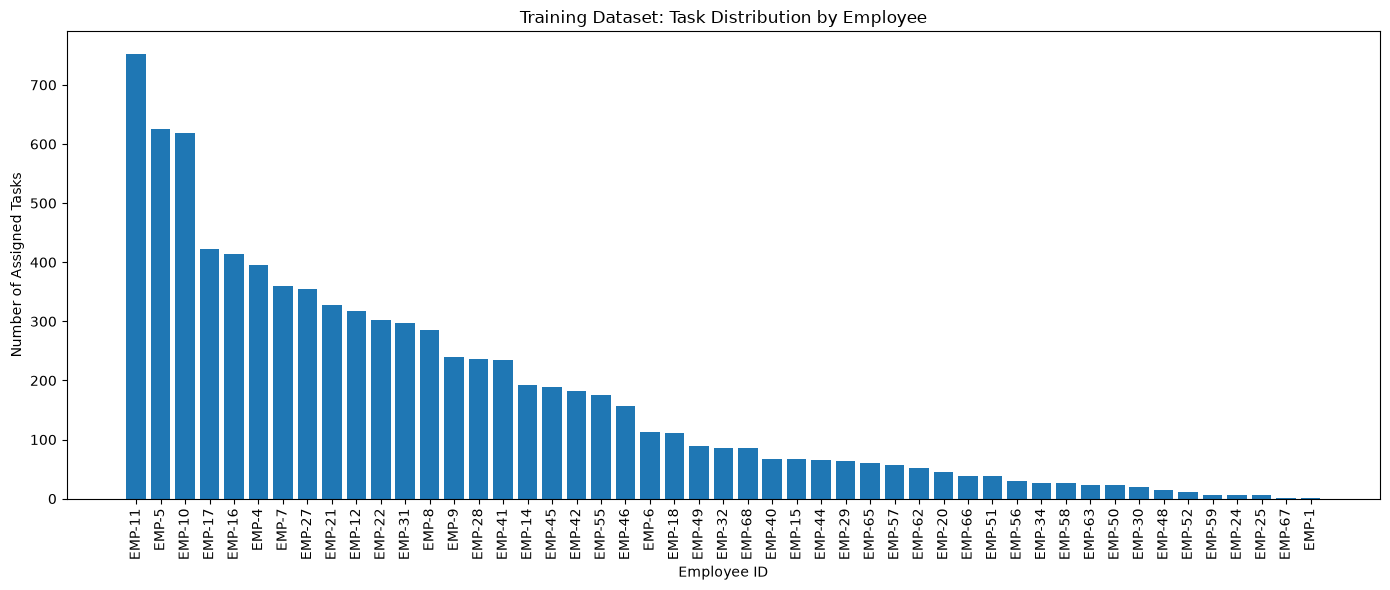

In [17]:
plt.figure(figsize=(14, 6))

plt.bar(
    imbalance_df["Employee_ID"],
    imbalance_df["Task_Count"]
)

plt.xlabel("Employee ID")
plt.ylabel("Number of Assigned Tasks")
plt.title("Training Dataset: Task Distribution by Employee")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [18]:
max_count = employee_counts.max()
min_count = employee_counts.min()

imbalance_ratio = max_count / min_count

print(f"Most frequent employee: {employee_counts.index[0]}")
print(f"Most frequent employee task count: {max_count}")

print(f"\nLeast frequent employee: {employee_counts.index[-1]}")
print(f"Least frequent employee task count: {min_count}")

print(f"\nMax/Min imbalance ratio: {imbalance_ratio:.2f}")

Most frequent employee: EMP-11
Most frequent employee task count: 753

Least frequent employee: EMP-1
Least frequent employee task count: 2

Max/Min imbalance ratio: 376.50


In [19]:
print("Employees with <= 5 tasks:")
display(imbalance_df[imbalance_df["Task_Count"] <= 5])

print("\nEmployees with <= 10 tasks:")
display(imbalance_df[imbalance_df["Task_Count"] <= 10])

print("\nEmployees with > 100 tasks:")
display(imbalance_df[imbalance_df["Task_Count"] > 100])

Employees with <= 5 tasks:


,Employee_ID,Task_Count,Percentage
47,EMP-67,2,0.02
48,EMP-1,2,0.02



Employees with <= 10 tasks:


,Employee_ID,Task_Count,Percentage
44,EMP-59,7,0.08
45,EMP-24,7,0.08
46,EMP-25,6,0.07
47,EMP-67,2,0.02
48,EMP-1,2,0.02



Employees with > 100 tasks:


,Employee_ID,Task_Count,Percentage
0,EMP-11,753,9.06
1,EMP-5,625,7.52
2,EMP-10,618,7.43
3,EMP-17,423,5.09
4,EMP-16,414,4.98
5,EMP-4,395,4.75
6,EMP-7,359,4.32
7,EMP-27,354,4.26
8,EMP-21,327,3.93
9,EMP-12,317,3.81


In [20]:
print("Total rows:", len(final_train_df))
print("Unique tasks:", final_train_df["Task_ID"].nunique())
print("Duplicate Task_ID rows:", final_train_df["Task_ID"].duplicated().sum())


Total rows: 8314
Unique tasks: 1709
Duplicate Task_ID rows: 6605


In [21]:
task_employee_check = (
    final_train_df.groupby("Task_ID")["Employee_ID"]
    .nunique()
    .sort_values(ascending=False)
)

print("Total unique tasks:", task_employee_check.shape[0])
print("Tasks with exactly 1 employee:", (task_employee_check == 1).sum())
print("Tasks with multiple employees:", (task_employee_check > 1).sum())
print("Maximum employees per task:", task_employee_check.max())

print("Tasks assigned to multiple employees:")
display(task_employee_check[task_employee_check > 1])


Total unique tasks: 1709
Tasks with exactly 1 employee: 1394
Tasks with multiple employees: 315
Maximum employees per task: 29
Tasks assigned to multiple employees:


Task_ID
TSK-183     29
TSK-435     24
TSK-1394    20
TSK-597     20
TSK-411     17
            ..
TSK-1398     2
TSK-112      2
TSK-972      2
TSK-2823     2
TSK-1119     2
Name: Employee_ID, Length: 315, dtype: int64

In [22]:
# ============================================================
# CHECK 1: TASK ID LEAKAGE BETWEEN TRAIN / VALIDATION / TEST
# ============================================================

train_tasks = set(final_train_df["Task_ID"].unique())
val_tasks = set(final_val_df["Task_ID"].unique())
test_tasks = set(final_test_df["Task_ID"].unique())

print("Train unique tasks:", len(train_tasks))
print("Validation unique tasks:", len(val_tasks))
print("Test unique tasks:", len(test_tasks))

print("\nTask overlap:")
print("Train ∩ Validation:", len(train_tasks & val_tasks))
print("Train ∩ Test:", len(train_tasks & test_tasks))
print("Validation ∩ Test:", len(val_tasks & test_tasks))




Train unique tasks: 1709
Validation unique tasks: 366
Test unique tasks: 367

Task overlap:
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [23]:
train_employees = set(final_train_df["Employee_ID"].unique())
val_employees = set(final_val_df["Employee_ID"].unique())
test_employees = set(final_test_df["Employee_ID"].unique())

print("Employee coverage:")
print("Train employees:", len(train_employees))
print("Validation employees:", len(val_employees))
print("Test employees:", len(test_employees))

print("Employees in Val not in Train:", sorted(val_employees - train_employees))
print("Employees in Test not in Train:", sorted(test_employees - train_employees))


Employee coverage:
Train employees: 49
Validation employees: 43
Test employees: 44
Employees in Val not in Train: []
Employees in Test not in Train: []


In [24]:
# ============================================================
# CHECK 3: TASK → EMPLOYEE DISTRIBUTION IN EACH SPLIT
# ============================================================

def task_employee_distribution(df, name):
    counts = df.groupby("Task_ID")["Employee_ID"].nunique()

    print(f"\n{name}")
    print("-" * 40)
    print("Unique tasks:", len(counts))
    print("1 employee:", (counts == 1).sum())
    print("Multiple employees:", (counts > 1).sum())
    print("Maximum employees/task:", counts.max())


task_employee_distribution(final_train_df, "TRAIN")
task_employee_distribution(final_val_df, "VALIDATION")
task_employee_distribution(final_test_df, "TEST")


TRAIN
----------------------------------------
Unique tasks: 1709
1 employee: 1394
Multiple employees: 315
Maximum employees/task: 29

VALIDATION
----------------------------------------
Unique tasks: 366
1 employee: 295
Multiple employees: 71
Maximum employees/task: 24

TEST
----------------------------------------
Unique tasks: 367
1 employee: 311
Multiple employees: 56
Maximum employees/task: 14
